# ABC Manufacturing Employee Attrition Analysis

## Data Loading, Inspection & Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load the dataset

In [2]:
data = pd.read_csv('../data/raw/abc_employee_attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### What Information is in this Data?

In [3]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### What is the shape of the Data?

In [4]:
#Shows the rows & columns - 1 employee per row, with info across 35 variables
data.shape

(1470, 35)

### Are there any missing values?

In [5]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Are there any duplicated rows?

In [6]:
data.duplicated().sum()

np.int64(0)

### Statistical description of the data

In [7]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### How many unique values exist?

In [8]:
data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [9]:
data.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

### Inspect Categories for selected categorical variables

In [10]:
data['Attrition'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [11]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Approximately **1 in 6 employees** in the dataset experienced attrition

In [12]:
data['Department'].unique()

<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

In [13]:
data['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Research & Development accounts for roughly two-thirds of the dataset, while Human Resources represents only a small fraction.

In [14]:
data['OverTime'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [15]:
data['OverTime'].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

Approximately 28% of the employees work overtime.

In [16]:
data['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [17]:
data['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

The dataset contains more male than female employees, with a 60/40 distribution.

In [18]:
data['JobRole'].unique()

<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

In [19]:
data['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

There is substantial variation in job-role representation.

### Let us inspect our select numerical variables

In [20]:
data[['Age', 'MonthlyIncome', 'TotalWorkingYears']].describe()

,Age,MonthlyIncome,TotalWorkingYears
count,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,11.279592
std,9.135373,4707.956783,7.780782
min,18.000000,1009.000000,0.000000
25%,30.000000,2911.000000,6.000000
50%,36.000000,4919.000000,10.000000
75%,43.000000,8379.000000,15.000000
max,60.000000,19999.000000,40.000000


### Age graphical Inspection

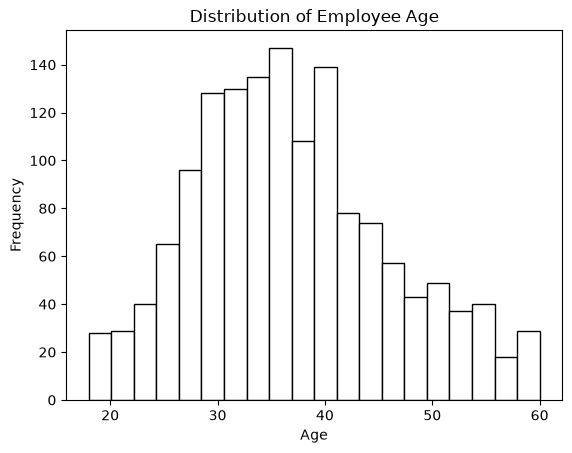

In [21]:
plt.hist(
    data['Age'],
    bins= 20,
    edgecolor='black',
    color='white'
)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Age')

plt.show()

The age distribution appears approximately bell-shaped, with employees concentrated around the mid-30s. Most observations appear to fall approximately between 30 and 40 years, although the middle 50% of observations range from 30 to 43 years.

Age does not appear to contain obvious extreme outliers. Employees below approximately 25 and above approximately 55 are less frequent, but their presence alone does not establish them as statistical outliers.

### Monthly Income graphical Inspection

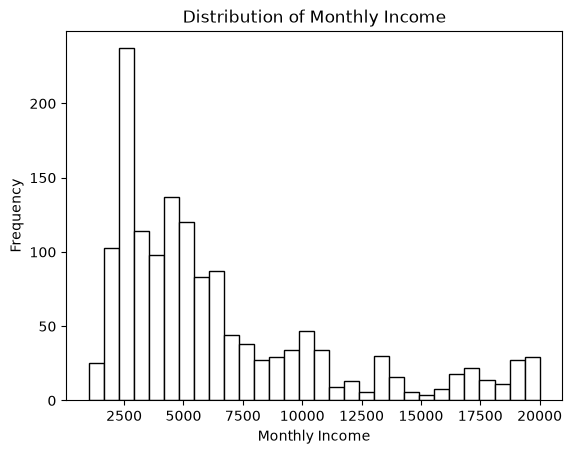

In [22]:
plt.hist(
    data['MonthlyIncome'],
    bins=30,
    edgecolor='black',
    color='white'
)

plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Income')

plt.show()

Monthly income appears right-skewed, with most employees concentrated in the lower-to-middle income range, approximately between 2,000 and 7,500, while a smaller number of employees have substantially higher incomes.

MonthlyIncome exhibits several higher-income observations that may be classified as potential outliers based on the distribution. These observations should not automatically be removed, as they may represent legitimate differences in employee compensation.

### Total Working Years graphical Inspection

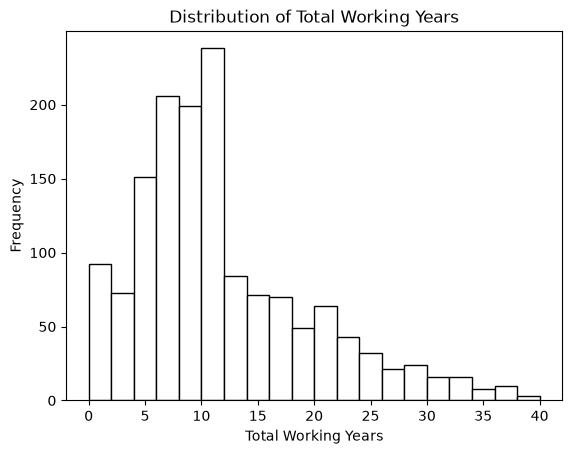

In [23]:
plt.hist(
    data['TotalWorkingYears'],
    bins=20,
    edgecolor='black',
    color='white'
)

plt.xlabel('Total Working Years')
plt.ylabel('Frequency')
plt.title('Distribution of Total Working Years')

plt.show()

Total working years appears right-skewed, with most employees having approximately 0–13 years of total working experience, while a smaller number of employees have considerably more experience, extending up to 40 years.

TotalWorkingYears contains potential high-end outliers above approximately 25 years. These observations may represent employees with extensive work experience and should therefore be investigated rather than automatically removed.